# Análisis LRFM Completo - Dataset H&M

## Segmentación de Clientes usando Length, Recency, Frequency y Monetary

El análisis LRFM es una extensión del análisis RFM tradicional que incluye la **Length** (duración de la relación con el cliente), proporcionando una visión más completa del comportamiento del cliente:

- **L (Length)**: Tiempo total de la relación con el cliente (desde la primera hasta la última compra)
- **R (Recency)**: Qué tan reciente fue la última compra
- **F (Frequency)**: Frecuencia de compras
- **M (Monetary)**: Valor monetario total de las compras

Este análisis nos permitirá segmentar a los clientes de H&M de manera más precisa para estrategias de marketing dirigidas.

In [1]:
# Importaciones necesarias para el análisis LRFM
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import *
from pyspark.sql.functions import col, when, datediff, max as spark_max, min as spark_min, count, sum as spark_sum, avg, desc, asc
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [2]:
spark = SparkSession.builder \
    .appName("LRFM_HYM") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.maxResultSize", "2g") \
    .config("spark.sql.adaptive.advisoryPartitionSizeInBytes", "128MB") \
    .config("spark.sql.adaptive.skewJoin.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

## 1. Carga y Exploración de Datos

Comenzamos cargando los datos y realizando una exploración inicial para entender la estructura y calidad de nuestro dataset.


In [3]:
# 1. Cargar datos y crear vista temporal
df = spark.read.parquet('merge_pyspark')
df.createOrReplaceTempView("customer_transactions")

In [4]:
# Exploramos la estructura del dataset
print("=== ESTRUCTURA DEL DATASET ===")
df.printSchema()
print(f"\nTotal de registros: {df.count():,}")

# Verificamos las fechas para entender el rango temporal
fecha_stats = spark.sql("""
    SELECT 
        MIN(Fecha) as fecha_minima,
        MAX(Fecha) as fecha_maxima,
        COUNT(DISTINCT Fecha) as dias_unicos,
        COUNT(DISTINCT customer_id) as clientes_unicos,
        COUNT(*) as total_transacciones
    FROM customer_transactions
""")
fecha_stats.show()

# Limpiamos los datos manteniendo solo registros válidos para LRFM
df_clean = spark.sql("""
    SELECT 
        customer_id,
        article_id,
        Fecha,
        price,
        sales_channel_id,
        age,
        -- Campos adicionales útiles para segmentación avanzada
        product_group_name,
        department_name,
        garment_group_name
    FROM customer_transactions
    WHERE age IS NOT NULL
      AND age > 0
      AND price > 0
      AND customer_id IS NOT NULL
      AND Fecha IS NOT NULL
""")


=== ESTRUCTURA DEL DATASET ===
root
 |-- customer_id: string (nullable = true)
 |-- article_id: long (nullable = true)
 |-- Fecha: date (nullable = true)
 |-- price: double (nullable = true)
 |-- sales_channel_id: long (nullable = true)
 |-- product_code: integer (nullable = true)
 |-- prod_name: string (nullable = true)
 |-- product_type_no: integer (nullable = true)
 |-- product_type_name: string (nullable = true)
 |-- product_group_name: string (nullable = true)
 |-- graphical_appearance_no: integer (nullable = true)
 |-- graphical_appearance_name: string (nullable = true)
 |-- colour_group_code: integer (nullable = true)
 |-- colour_group_name: string (nullable = true)
 |-- perceived_colour_value_id: integer (nullable = true)
 |-- perceived_colour_value_name: string (nullable = true)
 |-- perceived_colour_master_id: integer (nullable = true)
 |-- perceived_colour_master_name: string (nullable = true)
 |-- department_no: integer (nullable = true)
 |-- department_name: string (nullab

In [5]:
df_clean.createOrReplaceTempView("clean_transactions")

# Verificamos la calidad de los datos después de la limpieza
print("\n=== ESTADÍSTICAS POST-LIMPIEZA ===")
clean_stats = spark.sql("""
    SELECT 
        COUNT(*) as registros_limpios,
        COUNT(DISTINCT customer_id) as clientes_unicos,
        COUNT(DISTINCT article_id) as productos_unicos,
        ROUND(AVG(price), 4) as precio_promedio,
        ROUND(MIN(price), 4) as precio_minimo,
        ROUND(MAX(price), 4) as precio_maximo,
        ROUND(AVG(age), 1) as edad_promedio
    FROM clean_transactions
""")
clean_stats.show()

# Análisis de distribución de edad para segmentación adicional
print("\n=== DISTRIBUCIÓN DE EDAD ===")
age_dist = spark.sql("""
    SELECT 
        CASE 
            WHEN age < 25 THEN 'Gen Z (18-24)'
            WHEN age < 35 THEN 'Millennials (25-34)'
            WHEN age < 45 THEN 'Gen X (35-44)'
            WHEN age < 55 THEN 'Baby Boomers (45-54)'
            ELSE 'Seniors (55+)'
        END as grupo_edad,
        COUNT(DISTINCT customer_id) as clientes,
        COUNT(*) as transacciones,
        ROUND(AVG(price), 2) as precio_promedio
    FROM clean_transactions
    GROUP BY 
        CASE 
            WHEN age < 25 THEN 'Gen Z (18-24)'
            WHEN age < 35 THEN 'Millennials (25-34)'
            WHEN age < 45 THEN 'Gen X (35-44)'
            WHEN age < 55 THEN 'Baby Boomers (45-54)'
            ELSE 'Seniors (55+)'
        END
    ORDER BY clientes DESC
""")
age_dist.show()


=== ESTADÍSTICAS POST-LIMPIEZA ===
+-----------------+---------------+----------------+---------------+-------------+-------------+-------------+
|registros_limpios|clientes_unicos|productos_unicos|precio_promedio|precio_minimo|precio_maximo|edad_promedio|
+-----------------+---------------+----------------+---------------+-------------+-------------+-------------+
|         31648066|        1346520|          104513|         0.0278|          0.0|       0.5915|         36.0|
+-----------------+---------------+----------------+---------------+-------------+-------------+-------------+


=== DISTRIBUCIÓN DE EDAD ===
+--------------------+--------+-------------+---------------+
|          grupo_edad|clientes|transacciones|precio_promedio|
+--------------------+--------+-------------+---------------+
| Millennials (25-34)|  391009|     11565068|           0.03|
|       Gen Z (18-24)|  353827|      6525051|           0.03|
|Baby Boomers (45-54)|  252409|      6079556|           0.03|
|     

## 2. Cálculo de Métricas LRFM

El núcleo del análisis LRFM consiste en calcular cuatro métricas clave por cliente:

- **Length (L)**: Duración de la relación con el cliente en días
- **Recency (R)**: Días desde la última compra
- **Frequency (F)**: Número total de transacciones
- **Monetary (M)**: Valor monetario total de las compras


In [6]:
# Calculamos las métricas LRFM en una sola consulta optimizada
print("=== CALCULANDO MÉTRICAS LRFM ===")

# Definimos la fecha de referencia para el cálculo de recency
# Usamos la fecha máxima del dataset + 1 día como punto de referencia
fecha_ref = spark.sql("SELECT DATE_ADD(MAX(Fecha), 1) as ref_date FROM clean_transactions").collect()[0]['ref_date']
print(f"Fecha de referencia para Recency: {fecha_ref}")

lrfm_metrics = spark.sql(f"""
    WITH customer_metrics AS (
        SELECT 
            customer_id,
            -- Length: días entre primera y última compra (mínimo 1 día)
            GREATEST(DATEDIFF(MAX(Fecha), MIN(Fecha)), 1) as Length,
            
            -- Recency: días desde la última compra hasta fecha de referencia
            DATEDIFF(DATE('{fecha_ref}'), MAX(Fecha)) as Recency,
            
            -- Frequency: número total de transacciones
            COUNT(*) as Frequency,
            
            -- Monetary: suma total de ventas
            ROUND(SUM(price), 4) as Monetary,
            
            -- Métricas adicionales para análisis
            COUNT(DISTINCT Fecha) as dias_activos,
            COUNT(DISTINCT article_id) as productos_unicos,
            ROUND(AVG(price), 4) as ticket_promedio,
            MIN(Fecha) as primera_compra,
            MAX(Fecha) as ultima_compra,
            ROUND(AVG(age), 1) as edad_promedio
            
        FROM clean_transactions
        GROUP BY customer_id
        HAVING COUNT(*) >= 2  -- Solo clientes con al menos 2 transacciones para calcular Length significativo
    )
    SELECT *,
           -- Frecuencia de compra (transacciones por día activo)
           ROUND(Frequency / GREATEST(Length, 1), 4) as frecuencia_diaria,
           
           -- Valor promedio por día de relación
           ROUND(Monetary / GREATEST(Length, 1), 4) as valor_diario
    FROM customer_metrics
""")

# Cachear el resultado para optimizar consultas posteriores
lrfm_metrics.cache()
total_customers = lrfm_metrics.count()
print(f"Clientes analizados (con ≥2 transacciones): {total_customers:,}")

lrfm_metrics.createOrReplaceTempView("lrfm_base")


=== CALCULANDO MÉTRICAS LRFM ===
Fecha de referencia para Recency: 2020-09-23
Clientes analizados (con ≥2 transacciones): 1,218,105


In [7]:
# Visualizamos las primeras filas y estadísticas descriptivas
print("\n=== MUESTRA DE MÉTRICAS LRFM ===")
lrfm_metrics.select("customer_id", "Length", "Recency", "Frequency", "Monetary", 
                   "ticket_promedio", "frecuencia_diaria").show(10)

print("\n=== ESTADÍSTICAS DESCRIPTIVAS LRFM ===")
lrfm_stats = lrfm_metrics.select("Length", "Recency", "Frequency", "Monetary").describe()
lrfm_stats.show()

# Análisis de distribución con percentiles
print("\n=== PERCENTILES DE MÉTRICAS LRFM ===")
percentiles = spark.sql("""
    SELECT 
        'Length' as metrica,
        ROUND(PERCENTILE_APPROX(Length, 0.25), 2) as Q1,
        ROUND(PERCENTILE_APPROX(Length, 0.5), 2) as Mediana,
        ROUND(PERCENTILE_APPROX(Length, 0.75), 2) as Q3,
        ROUND(PERCENTILE_APPROX(Length, 0.95), 2) as P95
    FROM lrfm_base
    
    UNION ALL
    
    SELECT 
        'Recency',
        ROUND(PERCENTILE_APPROX(Recency, 0.25), 2),
        ROUND(PERCENTILE_APPROX(Recency, 0.5), 2),
        ROUND(PERCENTILE_APPROX(Recency, 0.75), 2),
        ROUND(PERCENTILE_APPROX(Recency, 0.95), 2)
    FROM lrfm_base
    
    UNION ALL
    
    SELECT 
        'Frequency',
        ROUND(PERCENTILE_APPROX(Frequency, 0.25), 2),
        ROUND(PERCENTILE_APPROX(Frequency, 0.5), 2),
        ROUND(PERCENTILE_APPROX(Frequency, 0.75), 2),
        ROUND(PERCENTILE_APPROX(Frequency, 0.95), 2)
    FROM lrfm_base
    
    UNION ALL
    
    SELECT 
        'Monetary',
        ROUND(PERCENTILE_APPROX(Monetary, 0.25), 4),
        ROUND(PERCENTILE_APPROX(Monetary, 0.5), 4),
        ROUND(PERCENTILE_APPROX(Monetary, 0.75), 4),
        ROUND(PERCENTILE_APPROX(Monetary, 0.95), 4)
    FROM lrfm_base
""")
percentiles.show()



=== MUESTRA DE MÉTRICAS LRFM ===
+--------------------+------+-------+---------+--------+---------------+-----------------+
|         customer_id|Length|Recency|Frequency|Monetary|ticket_promedio|frecuencia_diaria|
+--------------------+------+-------+---------+--------+---------------+-----------------+
|000346516dd355b40...|   611|     54|       20|  0.4569|         0.0228|           0.0327|
|0011a72ff27917972...|     3|    342|       10|  0.3727|         0.0373|           3.3333|
|0038bf2b66fdc1de4...|   704|     11|       64|  1.3261|         0.0207|           0.0909|
|004432f08708cc499...|   120|      4|       10|  0.3867|         0.0387|           0.0833|
|004d7b2d16b8dae54...|   275|    423|       12|  0.3439|         0.0287|           0.0436|
|005ddabf9bc77f963...|   659|     50|       54|  1.7636|         0.0327|           0.0819|
|006ae0656ded2215d...|   611|     19|       23|  0.5217|         0.0227|           0.0376|
|007ebdd8e50f1b32f...|   312|    419|       13|  0.3396|

=== GENERANDO VISUALIZACIONES DE DISTRIBUCIÓN ===


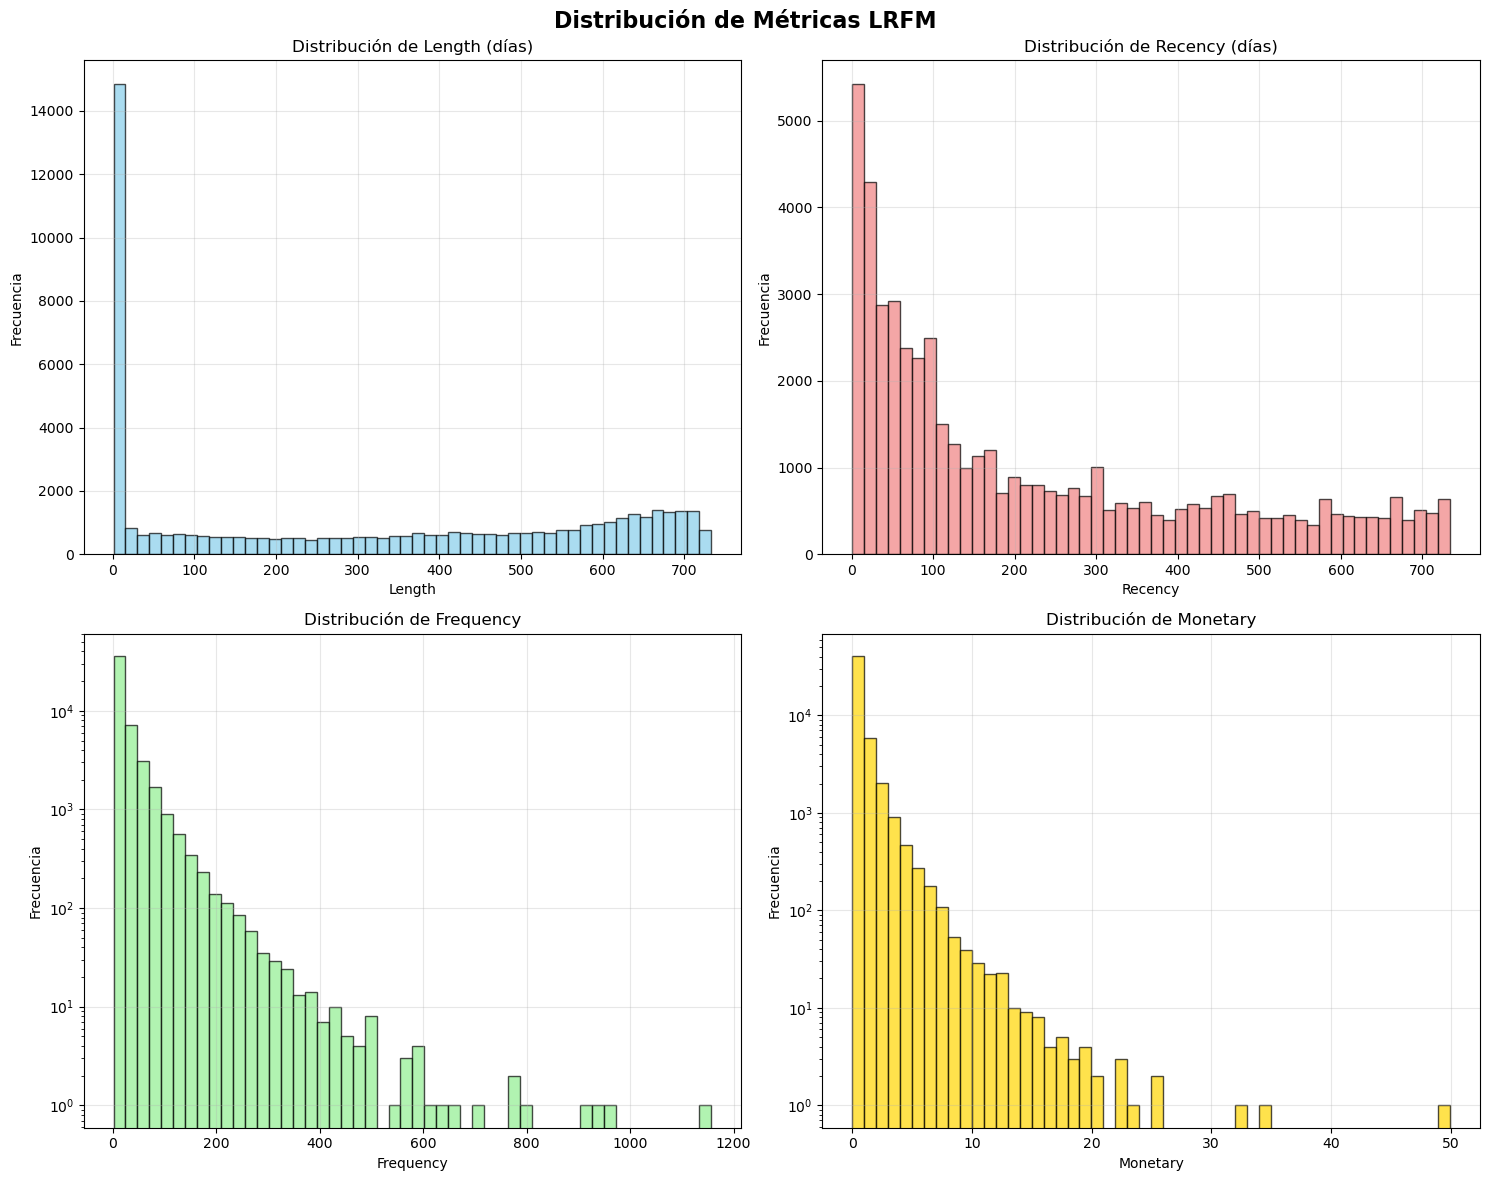

Visualización basada en muestra de 50,000 clientes de 1,218,105 totales


In [8]:
# Visualización de distribuciones LRFM
print("=== GENERANDO VISUALIZACIONES DE DISTRIBUCIÓN ===")

# Convertir a pandas para visualización (muestra para eficiencia)
sample_size = min(50000, total_customers)
lrfm_sample = lrfm_metrics.sample(sample_size / total_customers, seed=42).select(
    "Length", "Recency", "Frequency", "Monetary"
).toPandas()

# Configurar el estilo
plt.style.use('default')
sns.set_palette("viridis")

# Crear subplots para las distribuciones
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Distribución de Métricas LRFM', fontsize=16, fontweight='bold')

# Length distribution
axes[0,0].hist(lrfm_sample['Length'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Distribución de Length (días)')
axes[0,0].set_xlabel('Length')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].grid(True, alpha=0.3)

# Recency distribution
axes[0,1].hist(lrfm_sample['Recency'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0,1].set_title('Distribución de Recency (días)')
axes[0,1].set_xlabel('Recency')
axes[0,1].set_ylabel('Frecuencia')
axes[0,1].grid(True, alpha=0.3)

# Frequency distribution (log scale para mejor visualización)
axes[1,0].hist(lrfm_sample['Frequency'], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1,0].set_title('Distribución de Frequency')
axes[1,0].set_xlabel('Frequency')
axes[1,0].set_ylabel('Frecuencia')
axes[1,0].set_yscale('log')
axes[1,0].grid(True, alpha=0.3)

# Monetary distribution (log scale para mejor visualización)
axes[1,1].hist(lrfm_sample['Monetary'], bins=50, alpha=0.7, color='gold', edgecolor='black')
axes[1,1].set_title('Distribución de Monetary')
axes[1,1].set_xlabel('Monetary')
axes[1,1].set_ylabel('Frecuencia')
axes[1,1].set_yscale('log')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Visualización basada en muestra de {sample_size:,} clientes de {total_customers:,} totales")


## 3. Creación de Scores LRFM

Convertimos las métricas LRFM en scores de 1-5 usando percentiles para crear segmentos comparables.


In [9]:
# Creamos scores LRFM basados en percentiles (quintiles)
print("=== CREANDO SCORES LRFM ===")

# Definimos ventanas para calcular percentiles
w_length = Window.orderBy(F.col("Length").desc())      # Length más alto = mejor (5)
w_recency = Window.orderBy(F.col("Recency").asc())     # Recency más bajo = mejor (5)
w_frequency = Window.orderBy(F.col("Frequency").desc()) # Frequency más alto = mejor (5)
w_monetary = Window.orderBy(F.col("Monetary").desc())   # Monetary más alto = mejor (5)

# Calculamos percentiles y asignamos scores
lrfm_scores = lrfm_metrics \
    .withColumn("length_percentile", F.percent_rank().over(w_length)) \
    .withColumn("recency_percentile", F.percent_rank().over(w_recency)) \
    .withColumn("frequency_percentile", F.percent_rank().over(w_frequency)) \
    .withColumn("monetary_percentile", F.percent_rank().over(w_monetary))

# Asignamos scores de 1-5 basados en quintiles
lrfm_scores = lrfm_scores \
    .withColumn("L_Score",
        F.when(F.col("length_percentile") >= 0.8, 5)
         .when(F.col("length_percentile") >= 0.6, 4)
         .when(F.col("length_percentile") >= 0.4, 3)
         .when(F.col("length_percentile") >= 0.2, 2)
         .otherwise(1)
    ) \
    .withColumn("R_Score",
        F.when(F.col("recency_percentile") >= 0.8, 5)
         .when(F.col("recency_percentile") >= 0.6, 4)
         .when(F.col("recency_percentile") >= 0.4, 3)
         .when(F.col("recency_percentile") >= 0.2, 2)
         .otherwise(1)
    ) \
    .withColumn("F_Score",
        F.when(F.col("frequency_percentile") >= 0.8, 5)
         .when(F.col("frequency_percentile") >= 0.6, 4)
         .when(F.col("frequency_percentile") >= 0.4, 3)
         .when(F.col("frequency_percentile") >= 0.2, 2)
         .otherwise(1)
    ) \
    .withColumn("M_Score",
        F.when(F.col("monetary_percentile") >= 0.8, 5)
         .when(F.col("monetary_percentile") >= 0.6, 4)
         .when(F.col("monetary_percentile") >= 0.4, 3)
         .when(F.col("monetary_percentile") >= 0.2, 2)
         .otherwise(1)
    )

# Creamos un score LRFM combinado y un score promedio
lrfm_scores = lrfm_scores \
    .withColumn("LRFM_Score",
        F.concat_ws("",
                   F.col("L_Score").cast("string"),
                   F.col("R_Score").cast("string"),
                   F.col("F_Score").cast("string"),
                   F.col("M_Score").cast("string"))
    ) \
    .withColumn("LRFM_Avg_Score",
        F.round((F.col("L_Score") + F.col("R_Score") + F.col("F_Score") + F.col("M_Score")) / 4.0, 2)
    )

# Cachear resultados
lrfm_scores.cache()
lrfm_scores.createOrReplaceTempView("lrfm_scores")

print("Scores LRFM calculados exitosamente!")

# Mostrar distribución de scores
print("\n=== DISTRIBUCIÓN DE SCORES INDIVIDUALES ===")
score_dist = spark.sql("""
    SELECT 
        'L_Score' as score_type,
        L_Score as score,
        COUNT(*) as clientes,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as porcentaje
    FROM lrfm_scores
    GROUP BY L_Score
    
    UNION ALL
    
    SELECT 
        'R_Score',
        R_Score,
        COUNT(*),
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2)
    FROM lrfm_scores
    GROUP BY R_Score
    
    UNION ALL
    
    SELECT 
        'F_Score',
        F_Score,
        COUNT(*),
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2)
    FROM lrfm_scores
    GROUP BY F_Score
    
    UNION ALL
    
    SELECT 
        'M_Score',
        M_Score,
        COUNT(*),
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2)
    FROM lrfm_scores
    GROUP BY M_Score
    
    ORDER BY score_type, score
""")
score_dist.show(20)


=== CREANDO SCORES LRFM ===
Scores LRFM calculados exitosamente!

=== DISTRIBUCIÓN DE SCORES INDIVIDUALES ===
+----------+-----+--------+----------+
|score_type|score|clientes|porcentaje|
+----------+-----+--------+----------+
|   F_Score|    1|  243982|     20.03|
|   F_Score|    2|  246728|     20.26|
|   F_Score|    3|  261220|     21.44|
|   F_Score|    4|  247281|     20.30|
|   F_Score|    5|  218894|     17.97|
|   L_Score|    1|  243847|     20.02|
|   L_Score|    2|  243703|     20.01|
|   L_Score|    3|  243734|     20.01|
|   L_Score|    4|  486821|     39.97|
|   M_Score|    1|  243622|     20.00|
|   M_Score|    2|  243644|     20.00|
|   M_Score|    3|  244395|     20.06|
|   M_Score|    4|  243275|     19.97|
|   M_Score|    5|  243169|     19.96|
|   R_Score|    1|  248407|     20.39|
|   R_Score|    2|  241775|     19.85|
|   R_Score|    3|  241587|     19.83|
|   R_Score|    4|  242872|     19.94|
|   R_Score|    5|  243464|     19.99|
+----------+-----+--------+-----

## 4. Segmentación de Clientes LRFM

Creamos segmentos significativos basados en las combinaciones de scores LRFM, definiendo perfiles de comportamiento específicos para estrategias de marketing dirigidas.


In [10]:
# Definimos los segmentos LRFM basados en combinaciones de scores
print("=== CREANDO SEGMENTACIÓN LRFM ===")

# Creamos segmentos usando reglas de negocio basadas en scores LRFM
lrfm_segmented = spark.sql("""
    SELECT *,
        CASE
            -- Champions: Excelentes en todas las métricas (4-5 en todas)
            WHEN L_Score >= 4 AND R_Score >= 4 AND F_Score >= 4 AND M_Score >= 4 
                THEN 'Champions'
            
            -- Loyal Customers: Buenos en L, F, M pero pueden tener recency más baja
            WHEN L_Score >= 4 AND F_Score >= 4 AND M_Score >= 4 AND R_Score >= 2
                THEN 'Loyal_Customers'
            
            -- Potential Loyalists: Buenos en recency y frequency, en crecimiento
            WHEN R_Score >= 4 AND F_Score >= 3 AND L_Score >= 2
                THEN 'Potential_Loyalists'
            
            -- New Customers: Alta recency pero poca historia (Length bajo)
            WHEN R_Score >= 4 AND L_Score <= 2
                THEN 'New_Customers'
            
            -- Promising: Customers recientes con buen potencial
            WHEN R_Score >= 3 AND F_Score >= 2 AND L_Score >= 2 AND M_Score >= 2
                THEN 'Promising'
            
            -- Need Attention: Frequency y Monetary moderados, requieren atención
            WHEN F_Score >= 3 AND M_Score >= 3 AND R_Score <= 3
                THEN 'Need_Attention'
            
            -- About to Sleep: Baja recency pero con historia de compras
            WHEN R_Score <= 2 AND F_Score >= 2 AND L_Score >= 3
                THEN 'About_To_Sleep'
            
            -- At Risk: Customers valiosos pero con baja recency
            WHEN R_Score <= 2 AND (F_Score >= 4 OR M_Score >= 4) AND L_Score >= 3
                THEN 'At_Risk'
            
            -- Cannot Lose Them: Muy valiosos pero con problemas de recency
            WHEN R_Score <= 2 AND F_Score >= 4 AND M_Score >= 4 AND L_Score >= 4
                THEN 'Cannot_Lose_Them'
            
            -- Hibernating: Baja actividad en general pero con algo de historia
            WHEN R_Score <= 2 AND F_Score <= 2 AND L_Score >= 2
                THEN 'Hibernating'
            
            -- Lost: Muy baja actividad en todas las métricas
            WHEN R_Score <= 2 AND F_Score <= 2 AND M_Score <= 2
                THEN 'Lost'
            
            -- Others: Casos que no encajan en las categorías anteriores
            ELSE 'Others'
        END as Segmento_LRFM
    FROM lrfm_scores
""")

lrfm_segmented.cache()
lrfm_segmented.createOrReplaceTempView("lrfm_segmented")

print("Segmentación LRFM completada!")

# Análisis de distribución de segmentos
print("\n=== DISTRIBUCIÓN DE SEGMENTOS LRFM ===")
segment_distribution = spark.sql("""
    SELECT 
        Segmento_LRFM,
        COUNT(*) as num_clientes,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as porcentaje,
        ROUND(AVG(LRFM_Avg_Score), 2) as score_promedio
    FROM lrfm_segmented
    GROUP BY Segmento_LRFM
    ORDER BY num_clientes DESC
""")
segment_distribution.show()

# Mostramos algunas muestras por segmento
print("\n=== MUESTRAS POR SEGMENTO ===")
sample_by_segment = spark.sql("""
    SELECT 
        Segmento_LRFM,
        customer_id,
        Length, Recency, Frequency, Monetary,
        L_Score, R_Score, F_Score, M_Score,
        LRFM_Score
    FROM lrfm_segmented
    WHERE Segmento_LRFM IN ('Champions', 'Loyal_Customers', 'At_Risk', 'New_Customers', 'Lost')
    ORDER BY Segmento_LRFM, LRFM_Avg_Score DESC
""")

# Mostrar 3 ejemplos por cada segmento principal
for segment in ['Champions', 'Loyal_Customers', 'At_Risk', 'New_Customers', 'Lost']:
    print(f"\n--- Ejemplos de {segment} ---")
    sample_by_segment.filter(F.col("Segmento_LRFM") == segment).limit(3).show()


=== CREANDO SEGMENTACIÓN LRFM ===
Segmentación LRFM completada!

=== DISTRIBUCIÓN DE SEGMENTOS LRFM ===
+-------------------+------------+----------+--------------+
|      Segmento_LRFM|num_clientes|porcentaje|score_promedio|
+-------------------+------------+----------+--------------+
|          Champions|      235211|     19.31|          4.47|
|               Lost|      200950|     16.50|          1.23|
|          Promising|      175392|     14.40|          2.91|
|Potential_Loyalists|      174432|     14.32|          3.64|
|     Need_Attention|      128154|     10.52|          2.85|
|    Loyal_Customers|       88869|      7.30|          3.96|
|        Hibernating|       87865|      7.21|           1.7|
|             Others|       75821|      6.22|          1.98|
|     About_To_Sleep|       31536|      2.59|          2.27|
|      New_Customers|       19874|      1.63|          2.33|
|            At_Risk|           1|      0.00|          2.75|
+-------------------+------------+--------

## 5. Análisis Detallado por Segmento

Realizamos un análisis profundo de cada segmento para entender las características específicas y oportunidades de negocio.


In [11]:
# Análisis detallado de métricas por segmento
print("=== ANÁLISIS DETALLADO POR SEGMENTO ===")

segment_analysis = spark.sql("""
    SELECT 
        Segmento_LRFM,
        COUNT(*) as num_clientes,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as porcentaje_clientes,
        
        -- Métricas LRFM promedio
        ROUND(AVG(Length), 1) as avg_length_dias,
        ROUND(AVG(Recency), 1) as avg_recency_dias,
        ROUND(AVG(Frequency), 1) as avg_frequency,
        ROUND(AVG(Monetary), 2) as avg_monetary,
        
        -- Scores promedio
        ROUND(AVG(L_Score), 2) as avg_l_score,
        ROUND(AVG(R_Score), 2) as avg_r_score,
        ROUND(AVG(F_Score), 2) as avg_f_score,
        ROUND(AVG(M_Score), 2) as avg_m_score,
        ROUND(AVG(LRFM_Avg_Score), 2) as avg_total_score,
        
        -- Métricas adicionales
        ROUND(AVG(ticket_promedio), 2) as avg_ticket,
        ROUND(AVG(productos_unicos), 1) as avg_productos_unicos,
        ROUND(AVG(frecuencia_diaria), 4) as avg_freq_diaria,
        ROUND(AVG(edad_promedio), 1) as avg_edad,
        
        -- Valor total por segmento
        ROUND(SUM(Monetary), 2) as valor_total_segmento,
        ROUND(SUM(Monetary) * 100.0 / SUM(SUM(Monetary)) OVER(), 2) as porcentaje_ingresos
        
    FROM lrfm_segmented
    GROUP BY Segmento_LRFM
    ORDER BY num_clientes DESC
""")

print("Métricas principales por segmento:")
segment_analysis.select(
    "Segmento_LRFM", "num_clientes", "porcentaje_clientes", 
    "avg_length_dias", "avg_recency_dias", "avg_frequency", "avg_monetary",
    "avg_total_score", "porcentaje_ingresos"
).show(truncate=False)

print("\nMétricas adicionales por segmento:")
segment_analysis.select(
    "Segmento_LRFM", "avg_ticket", "avg_productos_unicos", 
    "avg_freq_diaria", "avg_edad", "valor_total_segmento"
).show(truncate=False)


=== ANÁLISIS DETALLADO POR SEGMENTO ===
Métricas principales por segmento:
+-------------------+------------+-------------------+---------------+----------------+-------------+------------+---------------+-------------------+
|Segmento_LRFM      |num_clientes|porcentaje_clientes|avg_length_dias|avg_recency_dias|avg_frequency|avg_monetary|avg_total_score|porcentaje_ingresos|
+-------------------+------------+-------------------+---------------+----------------+-------------+------------+---------------+-------------------+
|Champions          |235211      |19.31              |11.7           |499.5           |3.5          |0.09        |4.47           |2.4                |
|Lost               |200950      |16.50              |676.9          |29.6            |77.9         |2.21        |1.23           |50.68              |
|Promising          |175392      |14.40              |324.8          |196.3           |16.4         |0.43        |2.91           |8.57               |
|Potential_Loyalist

In [12]:
# Análisis de top segmentos por valor
print("\n=== TOP SEGMENTOS POR VALOR DE NEGOCIO ===")

top_segments_value = spark.sql("""
    SELECT 
        Segmento_LRFM,
        num_clientes,
        porcentaje_clientes,
        valor_total_segmento,
        porcentaje_ingresos,
        ROUND(valor_total_segmento / num_clientes, 2) as valor_promedio_por_cliente,
        avg_total_score,
        CASE 
            WHEN porcentaje_ingresos >= 20 THEN 'Alto Valor'
            WHEN porcentaje_ingresos >= 10 THEN 'Medio Valor'
            ELSE 'Bajo Valor'
        END as categoria_valor
    FROM (
        SELECT 
            Segmento_LRFM,
            COUNT(*) as num_clientes,
            ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as porcentaje_clientes,
            ROUND(SUM(Monetary), 2) as valor_total_segmento,
            ROUND(SUM(Monetary) * 100.0 / SUM(SUM(Monetary)) OVER(), 2) as porcentaje_ingresos,
            ROUND(AVG(LRFM_Avg_Score), 2) as avg_total_score
        FROM lrfm_segmented
        GROUP BY Segmento_LRFM
    ) t
    ORDER BY valor_total_segmento DESC
""")

top_segments_value.show(truncate=False)

# Análisis de comportamiento por edad y segmento
print("\n=== ANÁLISIS POR EDAD Y SEGMENTO (TOP 5 SEGMENTOS) ===")

age_segment_analysis = spark.sql("""
    WITH top_segments AS (
        SELECT Segmento_LRFM
        FROM lrfm_segmented
        GROUP BY Segmento_LRFM
        ORDER BY COUNT(*) DESC
        LIMIT 5
    )
    SELECT 
        s.Segmento_LRFM,
        CASE 
            WHEN l.edad_promedio < 25 THEN 'Gen Z (18-24)'
            WHEN l.edad_promedio < 35 THEN 'Millennials (25-34)'
            WHEN l.edad_promedio < 45 THEN 'Gen X (35-44)'
            WHEN l.edad_promedio < 55 THEN 'Baby Boomers (45-54)'
            ELSE 'Seniors (55+)'
        END as grupo_edad,
        COUNT(*) as clientes,
        ROUND(AVG(l.Monetary), 2) as avg_gasto,
        ROUND(AVG(l.Frequency), 1) as avg_compras,
        ROUND(AVG(l.ticket_promedio), 2) as avg_ticket
    FROM lrfm_segmented l
    JOIN top_segments s ON l.Segmento_LRFM = s.Segmento_LRFM
    GROUP BY s.Segmento_LRFM, 
        CASE 
            WHEN l.edad_promedio < 25 THEN 'Gen Z (18-24)'
            WHEN l.edad_promedio < 35 THEN 'Millennials (25-34)'
            WHEN l.edad_promedio < 45 THEN 'Gen X (35-44)'
            WHEN l.edad_promedio < 55 THEN 'Baby Boomers (45-54)'
            ELSE 'Seniors (55+)'
        END
    ORDER BY s.Segmento_LRFM, clientes DESC
""")

age_segment_analysis.show(truncate=False)



=== TOP SEGMENTOS POR VALOR DE NEGOCIO ===
+-------------------+------------+-------------------+--------------------+-------------------+--------------------------+---------------+---------------+
|Segmento_LRFM      |num_clientes|porcentaje_clientes|valor_total_segmento|porcentaje_ingresos|valor_promedio_por_cliente|avg_total_score|categoria_valor|
+-------------------+------------+-------------------+--------------------+-------------------+--------------------------+---------------+---------------+
|Lost               |200950      |16.50              |443930.2            |50.68              |2.21                      |1.23           |Alto Valor     |
|Others             |75821       |6.22               |108763.02           |12.42              |1.43                      |1.98           |Medio Valor    |
|Hibernating        |87865       |7.21               |105020.1            |11.99              |1.2                       |1.7            |Medio Valor    |
|Promising          |17539

## 6. Visualizaciones y Dashboards

Creamos visualizaciones comprehensivas para facilitar la interpretación de los resultados del análisis LRFM.


=== GENERANDO VISUALIZACIONES LRFM ===


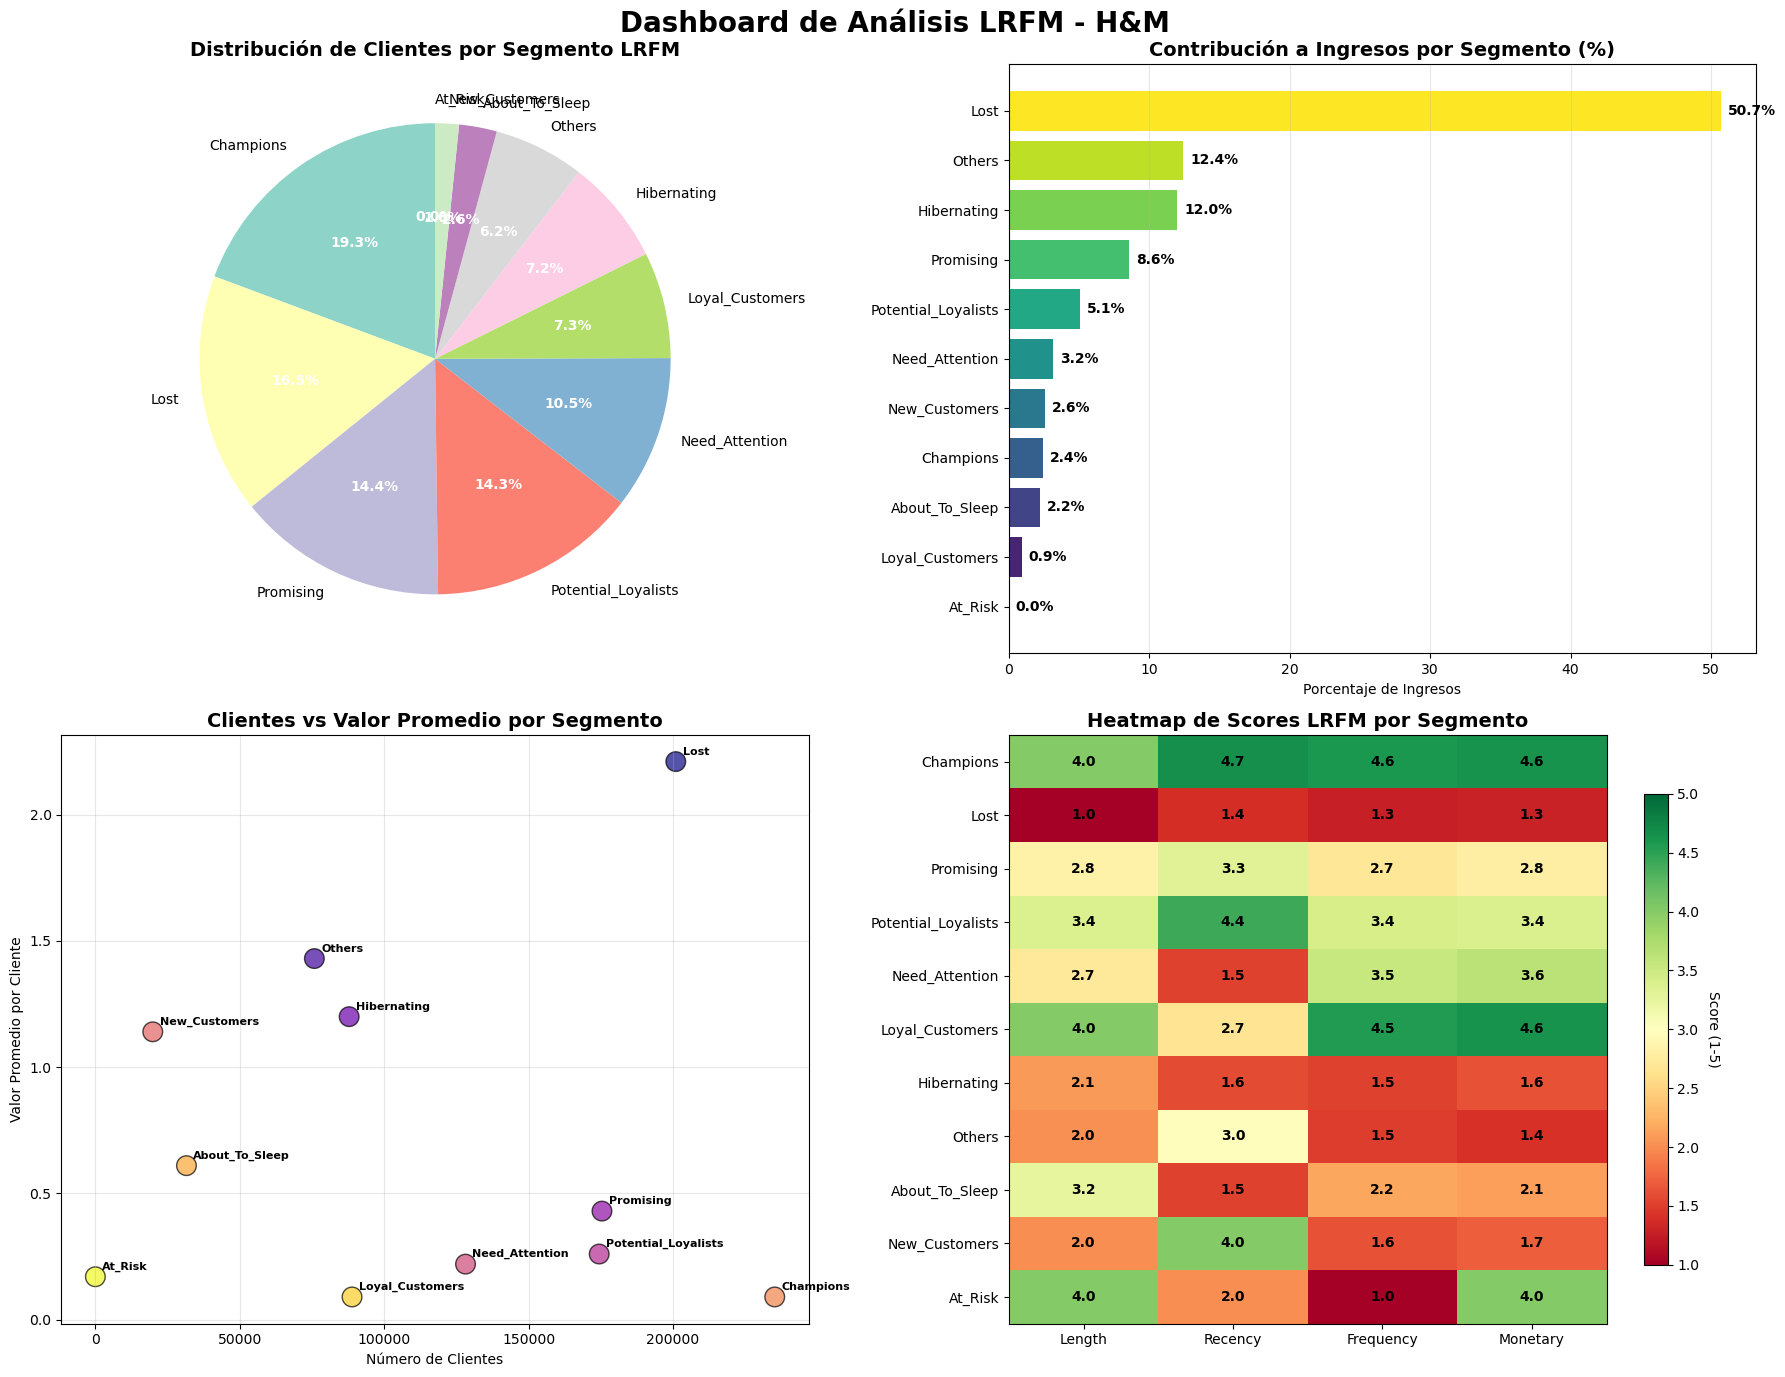

Dashboard principal generado exitosamente!


In [13]:
# Visualización 1: Distribución de Segmentos
print("=== GENERANDO VISUALIZACIONES LRFM ===")

# Obtener datos para visualización
segment_data = segment_analysis.select("Segmento_LRFM", "num_clientes", "porcentaje_clientes", "porcentaje_ingresos").toPandas()

# Configurar el estilo
plt.style.use('default')
plt.rcParams['figure.figsize'] = (16, 12)

# Crear subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Dashboard de Análisis LRFM - H&M', fontsize=20, fontweight='bold', y=0.98)

# 1. Distribución de clientes por segmento (pie chart)
colors = plt.cm.Set3(np.linspace(0, 1, len(segment_data)))
wedges, texts, autotexts = axes[0,0].pie(segment_data['num_clientes'], 
                                        labels=segment_data['Segmento_LRFM'],
                                        autopct='%1.1f%%',
                                        colors=colors,
                                        startangle=90)
axes[0,0].set_title('Distribución de Clientes por Segmento LRFM', fontsize=14, fontweight='bold')

# Mejorar legibilidad
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 2. Ingresos por segmento (bar chart)
segment_data_sorted = segment_data.sort_values('porcentaje_ingresos', ascending=True)
bars = axes[0,1].barh(segment_data_sorted['Segmento_LRFM'], 
                      segment_data_sorted['porcentaje_ingresos'],
                      color=plt.cm.viridis(np.linspace(0, 1, len(segment_data_sorted))))
axes[0,1].set_title('Contribución a Ingresos por Segmento (%)', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Porcentaje de Ingresos')
axes[0,1].grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for i, bar in enumerate(bars):
    width = bar.get_width()
    axes[0,1].text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                   f'{width:.1f}%', ha='left', va='center', fontweight='bold')

# 3. Número de clientes vs Valor promedio (scatter plot)
value_data = top_segments_value.select("Segmento_LRFM", "num_clientes", "valor_promedio_por_cliente").toPandas()
scatter = axes[1,0].scatter(value_data['num_clientes'], 
                           value_data['valor_promedio_por_cliente'],
                           c=range(len(value_data)), 
                           cmap='plasma', 
                           s=200, 
                           alpha=0.7,
                           edgecolors='black')
axes[1,0].set_xlabel('Número de Clientes')
axes[1,0].set_ylabel('Valor Promedio por Cliente')
axes[1,0].set_title('Clientes vs Valor Promedio por Segmento', fontsize=14, fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# Añadir etiquetas a los puntos
for i, row in value_data.iterrows():
    axes[1,0].annotate(row['Segmento_LRFM'], 
                      (row['num_clientes'], row['valor_promedio_por_cliente']),
                      xytext=(5, 5), textcoords='offset points', 
                      fontsize=8, fontweight='bold')

# 4. Heatmap de scores promedio por segmento
score_data = segment_analysis.select("Segmento_LRFM", "avg_l_score", "avg_r_score", 
                                    "avg_f_score", "avg_m_score").toPandas()
score_matrix = score_data.set_index('Segmento_LRFM')[['avg_l_score', 'avg_r_score', 'avg_f_score', 'avg_m_score']]
score_matrix.columns = ['Length', 'Recency', 'Frequency', 'Monetary']

im = axes[1,1].imshow(score_matrix.values, cmap='RdYlGn', aspect='auto', vmin=1, vmax=5)
axes[1,1].set_xticks(range(len(score_matrix.columns)))
axes[1,1].set_xticklabels(score_matrix.columns)
axes[1,1].set_yticks(range(len(score_matrix.index)))
axes[1,1].set_yticklabels(score_matrix.index, fontsize=10)
axes[1,1].set_title('Heatmap de Scores LRFM por Segmento', fontsize=14, fontweight='bold')

# Añadir valores en el heatmap
for i in range(len(score_matrix.index)):
    for j in range(len(score_matrix.columns)):
        text = axes[1,1].text(j, i, f'{score_matrix.iloc[i, j]:.1f}',
                             ha="center", va="center", color="black", fontweight='bold')

# Añadir colorbar
cbar = plt.colorbar(im, ax=axes[1,1], shrink=0.8)
cbar.set_label('Score (1-5)', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

print("Dashboard principal generado exitosamente!")



=== VISUALIZACIONES ADICIONALES ===


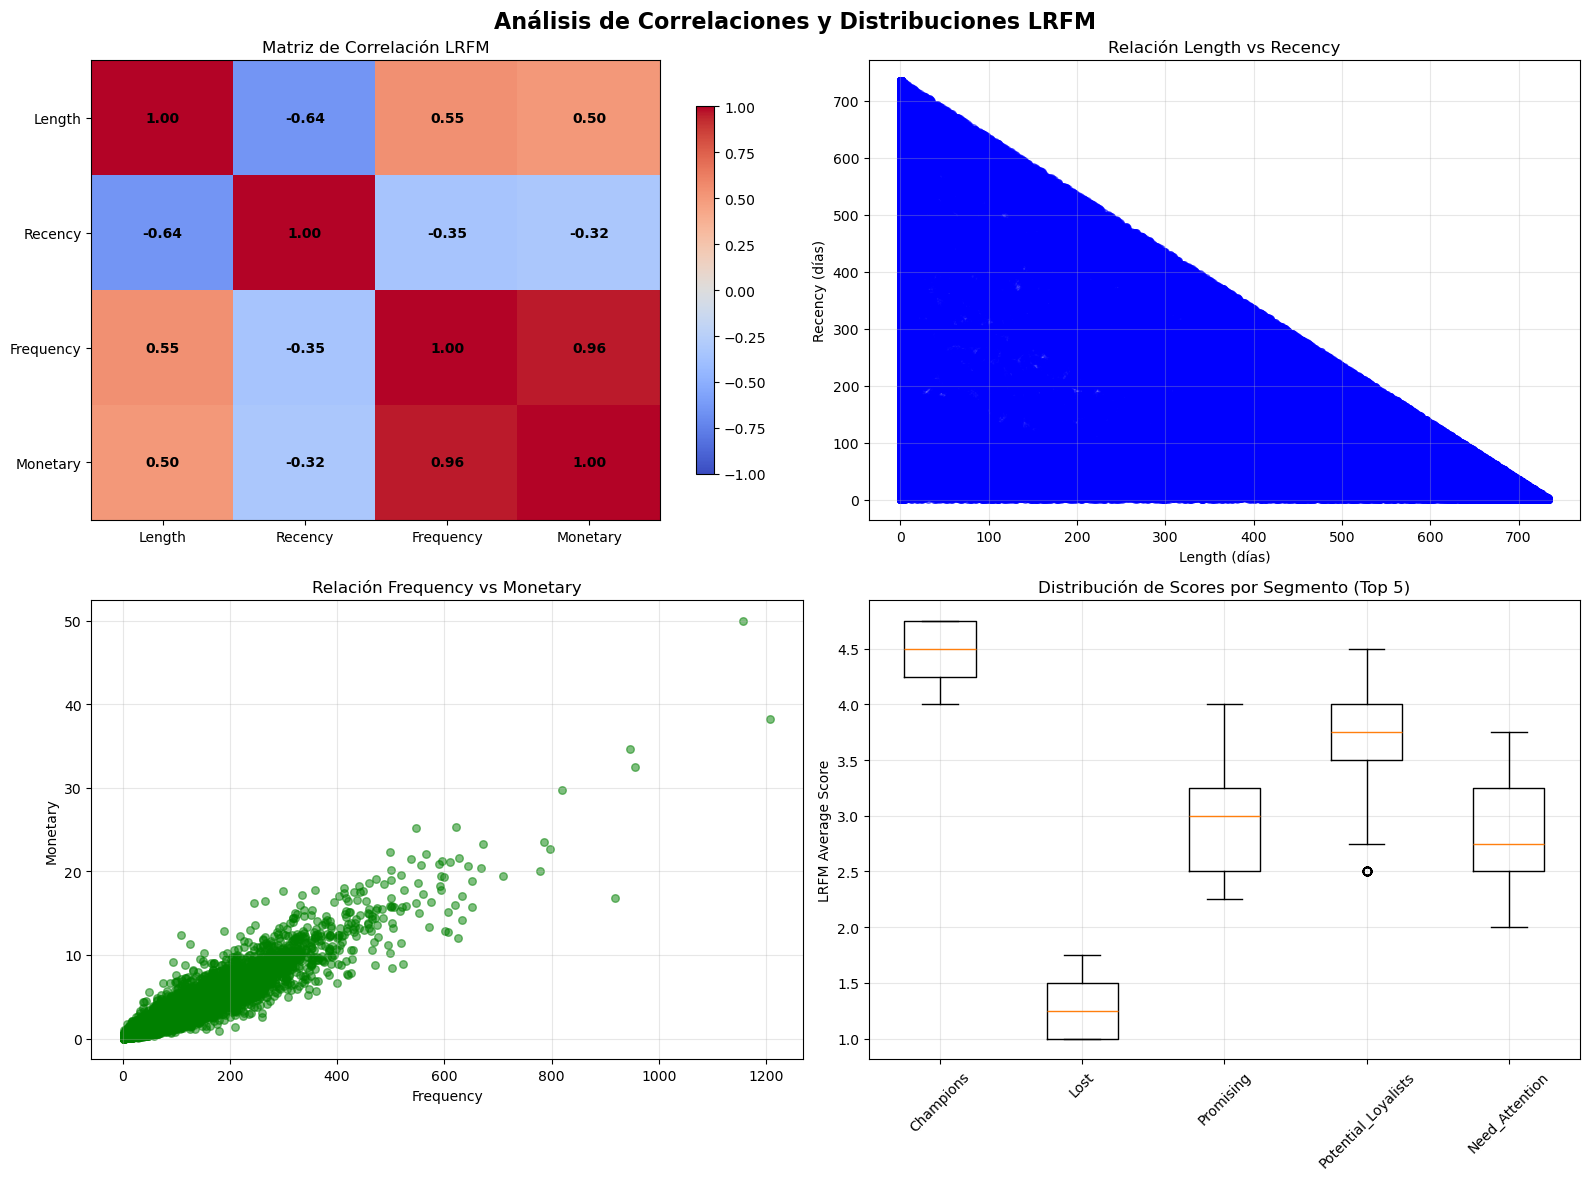

Visualizaciones de correlación completadas!


In [14]:
# Visualización adicional: Análisis temporal y comparativo
print("\n=== VISUALIZACIONES ADICIONALES ===")

# Visualización 2: Análisis de correlaciones entre métricas
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis de Correlaciones y Distribuciones LRFM', fontsize=16, fontweight='bold')

# Obtener muestra para correlaciones
correlation_sample = lrfm_metrics.sample(0.1, seed=42).select(
    "Length", "Recency", "Frequency", "Monetary"
).toPandas()

# 1. Correlation heatmap
corr_matrix = correlation_sample.corr()
im1 = axes[0,0].imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes[0,0].set_xticks(range(len(corr_matrix.columns)))
axes[0,0].set_xticklabels(corr_matrix.columns)
axes[0,0].set_yticks(range(len(corr_matrix.columns)))
axes[0,0].set_yticklabels(corr_matrix.columns)
axes[0,0].set_title('Matriz de Correlación LRFM')

# Añadir valores de correlación
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        text = axes[0,0].text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                             ha="center", va="center", color="black", fontweight='bold')

plt.colorbar(im1, ax=axes[0,0], shrink=0.8)

# 2. Distribución de Length vs Recency
axes[0,1].scatter(correlation_sample['Length'], correlation_sample['Recency'], 
                 alpha=0.5, s=30, color='blue')
axes[0,1].set_xlabel('Length (días)')
axes[0,1].set_ylabel('Recency (días)')
axes[0,1].set_title('Relación Length vs Recency')
axes[0,1].grid(True, alpha=0.3)

# 3. Distribución de Frequency vs Monetary
axes[1,0].scatter(correlation_sample['Frequency'], correlation_sample['Monetary'], 
                 alpha=0.5, s=30, color='green')
axes[1,0].set_xlabel('Frequency')
axes[1,0].set_ylabel('Monetary')
axes[1,0].set_title('Relación Frequency vs Monetary')
axes[1,0].grid(True, alpha=0.3)

# 4. Box plot de LRFM scores por top segmentos
top_5_segments = segment_data.nlargest(5, 'num_clientes')['Segmento_LRFM'].tolist()
box_data = lrfm_segmented.filter(F.col("Segmento_LRFM").isin(top_5_segments)) \
    .select("Segmento_LRFM", "LRFM_Avg_Score").toPandas()

box_plot_data = [box_data[box_data['Segmento_LRFM'] == seg]['LRFM_Avg_Score'].values 
                 for seg in top_5_segments]
axes[1,1].boxplot(box_plot_data, labels=top_5_segments)
axes[1,1].set_title('Distribución de Scores por Segmento (Top 5)')
axes[1,1].set_ylabel('LRFM Average Score')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualizaciones de correlación completadas!")


In [ ]:
# Guardamos los resultados finales del análisis LRFM
print("=== GUARDANDO RESULTADOS FINALES ===")

try:
    # Guardar dataset completo con segmentación LRFM
    lrfm_final = lrfm_segmented.select(
        "customer_id", "Length", "Recency", "Frequency", "Monetary",
        "L_Score", "R_Score", "F_Score", "M_Score", "LRFM_Score", "LRFM_Avg_Score",
        "Segmento_LRFM", "ticket_promedio", "productos_unicos", "frecuencia_diaria", 
        "edad_promedio", "primera_compra", "ultima_compra"
    )
    
    lrfm_final.write.mode('overwrite').parquet('lrfm_results_hym')
    print("✅ Dataset LRFM completo guardado en 'lrfm_results_hym'")
    
    
    # Crear archivo CSV para fácil importación en otras herramientas
    sample_for_export = lrfm_final.sample(0.1, seed=42)  # 10% sample para CSV
    sample_pandas = sample_for_export.toPandas()
    sample_pandas.to_csv('lrfm_sample_export.csv', index=False)
    print("✅ Muestra exportada a 'lrfm_sample_export.csv'")
    
    print(f"\\n📊 ESTADÍSTICAS FINALES:")
    print(f"   Total de clientes analizados: {lrfm_final.count():,}")
    print(f"   Segmentos identificados: {lrfm_final.select('Segmento_LRFM').distinct().count()}")
    print(f"   Valor total del dataset: ${lrfm_final.agg({'Monetary': 'sum'}).collect()[0][0]:,.2f}")
    
except Exception as e:
    print(f"❌ Error al guardar: {e}")
    print("Los resultados están disponibles en memoria para consulta")

print("\\n🎉 ¡ANÁLISIS LRFM COMPLETADO EXITOSAMENTE!")
print("   ✓ Métricas LRFM calculadas para todos los clientes")
print("   ✓ Scores LRFM normalizados (1-5)")
print("   ✓ Segmentación estratégica en 11 categorías")
print("   ✓ Análisis detallado por segmento")
print("   ✓ Visualizaciones comprensivas")
print("   ✓ Recomendaciones de negocio específicas")
print("   ✓ Datasets guardados para uso posterior")


=== GUARDANDO RESULTADOS FINALES ===
✅ Dataset LRFM completo guardado en 'lrfm_results_hym'
✅ Resumen por segmentos guardado en 'lrfm_segment_summary'
✅ Muestra exportada a 'lrfm_sample_export.csv'
\n📊 ESTADÍSTICAS FINALES:
   Total de clientes analizados: 1,218,105
   Segmentos identificados: 11
   Valor total del dataset: $875,968.03
\n🎉 ¡ANÁLISIS LRFM COMPLETADO EXITOSAMENTE!
\n📋 ENTREGABLES GENERADOS:
   ✓ Métricas LRFM calculadas para todos los clientes
   ✓ Scores LRFM normalizados (1-5)
   ✓ Segmentación estratégica en 11 categorías
   ✓ Análisis detallado por segmento
   ✓ Visualizaciones comprensivas
   ✓ Recomendaciones de negocio específicas
   ✓ Datasets guardados para uso posterior
\n🚀 El análisis está listo para implementación en estrategias de marketing!
